In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Nimbus Roman"


import sys, os
sys.path.append(os.path.join(os.getcwd(), ".."))

from ml_force.models import MorrisLecarBlock

In [8]:
class LIF:
    v_th = -55  # mV
    v_reset = -75.  # mV
    v_peak = 0.     # mV
    tau_m = 100.0    # ms
    g_L = 10.
    v_init = -75.   # mV
    E_L = -75.      # mV
    t_ref = 2.      # ms
    
    def __init__(self, N, T, dt):
        self.t = np.arange(0, T, dt)
        self.dt = dt
        self.nt = self.t.size
        self.v = LIF.v_init + 10 * np.random.rand(N, self.nt)
    
    def v_dot(self, v, I:float=50.):
        return (-(v-LIF.E_L) + I / LIF.g_L) / LIF.tau_m
    
    def generate(self, I=600):
        for i in range(1, self.nt):
            v = self.v[:, i-1] + self.v_dot(self.v[:, i-1], I) * self.dt
            mask = (v > LIF.v_th)
            self.v[mask, i-1] = LIF.v_peak
            v[mask] = LIF.v_reset
            self.v[:, i] = v
        return self.v

In [11]:
lif = LIF(1, 1000, .01)
lif_trace = lif.generate(I=300)

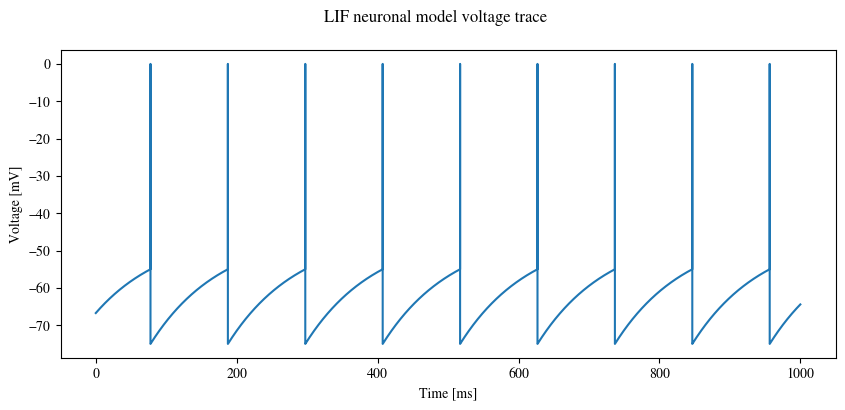

In [15]:
fig = plt.figure(figsize=(10, 4), num=1)
ax = fig.subplots()

ax.plot(lif.t, lif.v.T)
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Voltage [mV]")
plt.suptitle("LIF neuronal model voltage trace")
fig.savefig("img/lif_model_trace.jpg", dpi=600, bbox_inches='tight')
plt.show(fig)
plt.close(fig)

In [16]:
T = 1000
dt = 0.01
t = np.arange(0, T, dt)
nt = t.size

N = 10
sup = np.zeros((N, nt))

block = MorrisLecarBlock(sup, dt, T, 100, N=5, gbar=0)

rands, v_trace, dec_trace = block.render(100, 0, 20, False, 300, 1, True)

100%|██████████| 100000/100000 [00:04<00:00, 23543.00it/s]


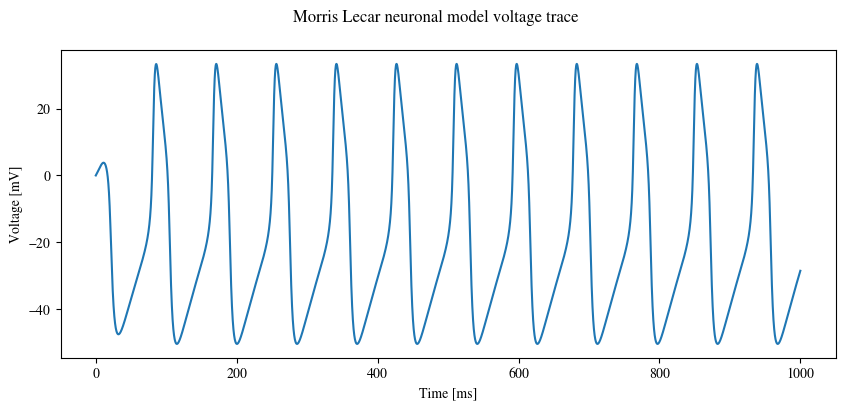

In [17]:
fig = plt.figure(figsize=(10, 4), num=2)
ax = fig.subplots()

ax.plot(t, v_trace[:, 0])
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Voltage [mV]")
plt.suptitle("Morris Lecar neuronal model voltage trace")
fig.savefig("img/ml_model_trace.jpg", dpi=600, bbox_inches='tight')
plt.show(fig)
plt.close(fig)